Complete the exercises below For **Assignment #4**.

Use **Markdown** cells for the non-code answers.

In this assignment we will work with the data underlying the *FiveThirtyEight* article ["Higher Rates Of Hate Crimes Are Tied To Income Inequality"](https://fivethirtyeight.com/features/higher-rates-of-hate-crimes-are-tied-to-income-inequality/).

Load the `tidymodels`, `readr`, and `moderndive` packages in the cell below.

In [56]:
library(tidymodels)
library(readr)
library(moderndive)

We can read the data from a **CSV file** at the following URL: [http://bit.ly/2ItxYg3](http://bit.ly/2ItxYg3).

Use the `read_csv` function to read the data into our R session. Call the new table `hate_crimes`.

In [57]:
hate_crimes <- read_csv("hate_crimes.csv")




Rows: 51 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (5): state, median_house_inc, trump_support, unemployment, urbanization
dbl (4): share_pop_metro, hs, hate_crimes, income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Next, let’s add the high-school degree variable into the mix by creating a scatterplot showing:

- Income on the y-axis (this is the `income` variable)
- Percent of adults 25 or older with a high school degree on the x-axis (this is the `hs` variable)
- The points colored by level of urbanization in a region (this is the variable `urbanization`)


**In addition, add a line of best fit (regression line) for each level of the variable urbanization (one for “low”, one for “high”).**

*Add the regression lines to the plot using the `geom_parallel_slopes` function from the `moderndive` package. This function will draw the regression lines based on fitting a regression model with parallel slopes (i.e., with no interaction between `hs` and `urbanization`).*

In [58]:
hate_crimes |> sample_n(10)

state,median_house_inc,share_pop_metro,hs,hate_crimes,trump_support,unemployment,urbanization,income
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
North Carolina,low,0.76,84,0.244,medium,high,low,46784
New Jersey,high,1.00,87,0.078,low,high,high,65243
California,high,0.97,81,0.256,low,high,high,60487
Louisiana,low,0.81,82,0.110,high,high,high,42406
Maryland,high,0.97,89,0.370,low,low,high,76165
Florida,low,0.96,85,0.188,medium,high,high,46140
Vermont,high,0.35,91,0.324,low,low,low,60708
Illinois,low,0.90,86,0.195,low,high,high,54916
Massachusetts,high,0.97,89,0.631,low,low,high,63151


In [59]:
# check data set and omit na values
glimpse(hate_crimes)
hate_crimes <- hate_crimes %>% drop_na()
glimpse(hate_crimes)

Rows: 51
Columns: 9
$ state            <chr> "New Mexico", "Maine", "New York", "Illinois", "Delaw~
$ median_house_inc <chr> "low", "low", "low", "low", "high", "high", "high", "~
$ share_pop_metro  <dbl> 0.69, 0.54, 0.94, 0.90, 0.90, 1.00, 0.87, 0.86, 0.97,~
$ hs               <dbl> 83, 90, 85, 86, 87, 85, 89, 90, 81, 91, 89, 89, 87, 8~
$ hate_crimes      <dbl> 0.295, 0.616, 0.351, 0.195, 0.323, 0.095, 0.833, 0.67~
$ trump_support    <chr> "low", "low", "low", "low", "low", "low", "low", "low~
$ unemployment     <chr> "high", "low", "low", "high", "low", "high", "high", ~
$ urbanization     <chr> "low", "low", "high", "high", "high", "high", "high",~
$ income           <dbl> 46686, 51710, 54310, 54916, 57522, 58633, 58875, 5906~
Rows: 45
Columns: 9
$ state            <chr> "New Mexico", "Maine", "New York", "Illinois", "Delaw~
$ median_house_inc <chr> "low", "low", "low", "low", "high", "high", "high", "~
$ share_pop_metro  <dbl> 0.69, 0.54, 0.94, 0.90, 0.90, 1.00, 0.87, 0.86, 0.97,~


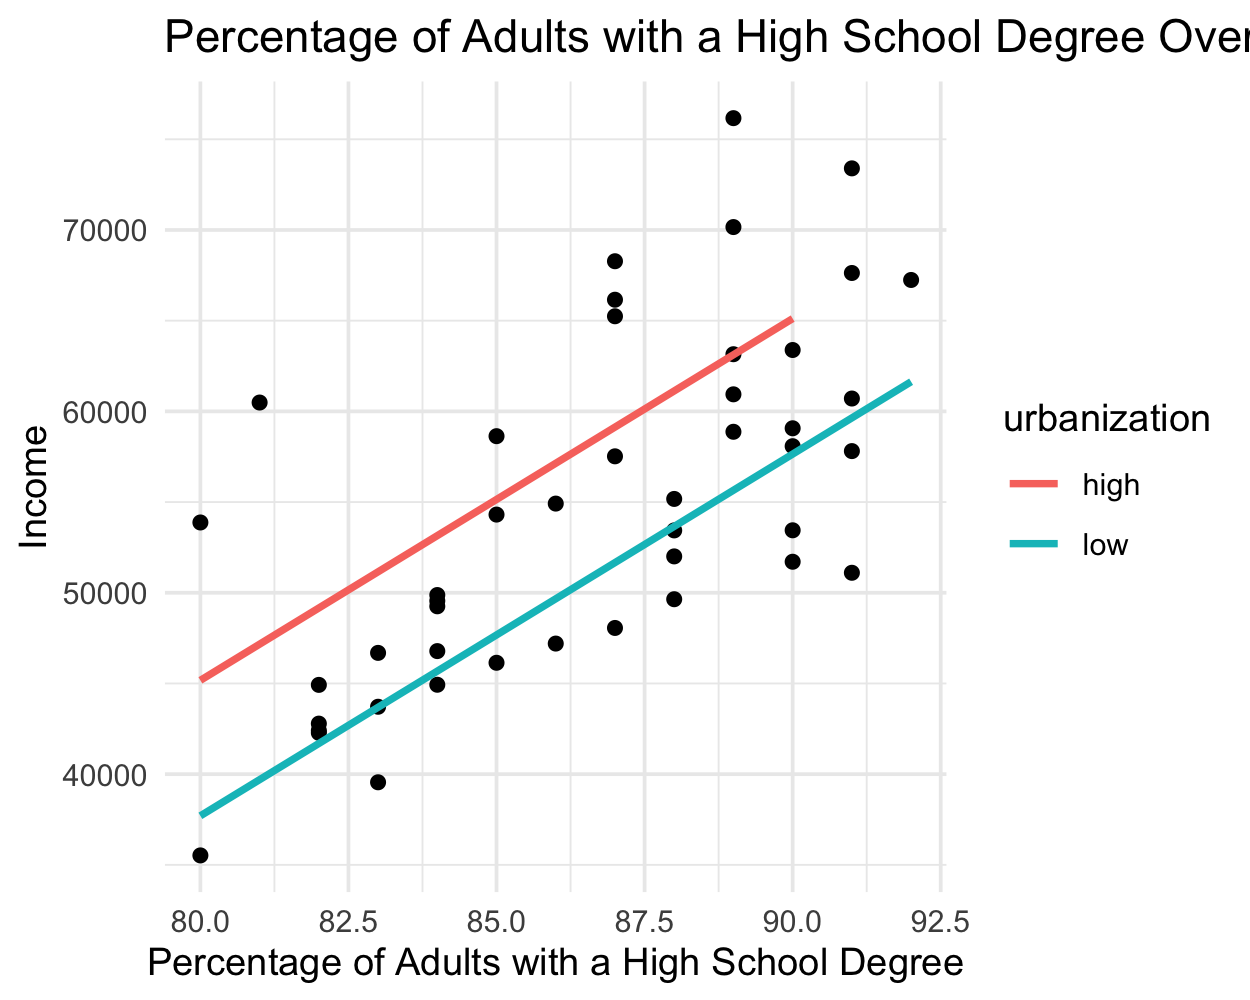

In [60]:
# add hue = "urbanization" to the aes() function to color the points by urbanization level
# draw prallel lines for each urbanization level using geom_smooth() with method = "lm" and se = FALSE

ggplot(data = hate_crimes, aes(x = hs, y = income, hue = urbanization)) +
  geom_point() +
  geom_parallel_slopes( se = FALSE, mapping = aes(color = urbanization)) +
  labs(title = "Percentage of Adults with a High School Degree Over Time",
       x = "Percentage of Adults with a High School Degree",
       y = "Income") +
  theme_minimal()
  


❓Which regression line (high urbanization or low urbanization) appears to have the larger intercept?

**Answer:**

High urbanization has a larger intercept.



Now let’s create a second scatterplot using the same variables, but this time draw the regression lines using `geom_smooth(method = "lm")`, which will allow for separate, non-parallel slopes for each urbanization group. 

**Code your scatter plot in the cell below.**

`geom_smooth()` using formula = 'y ~ x'


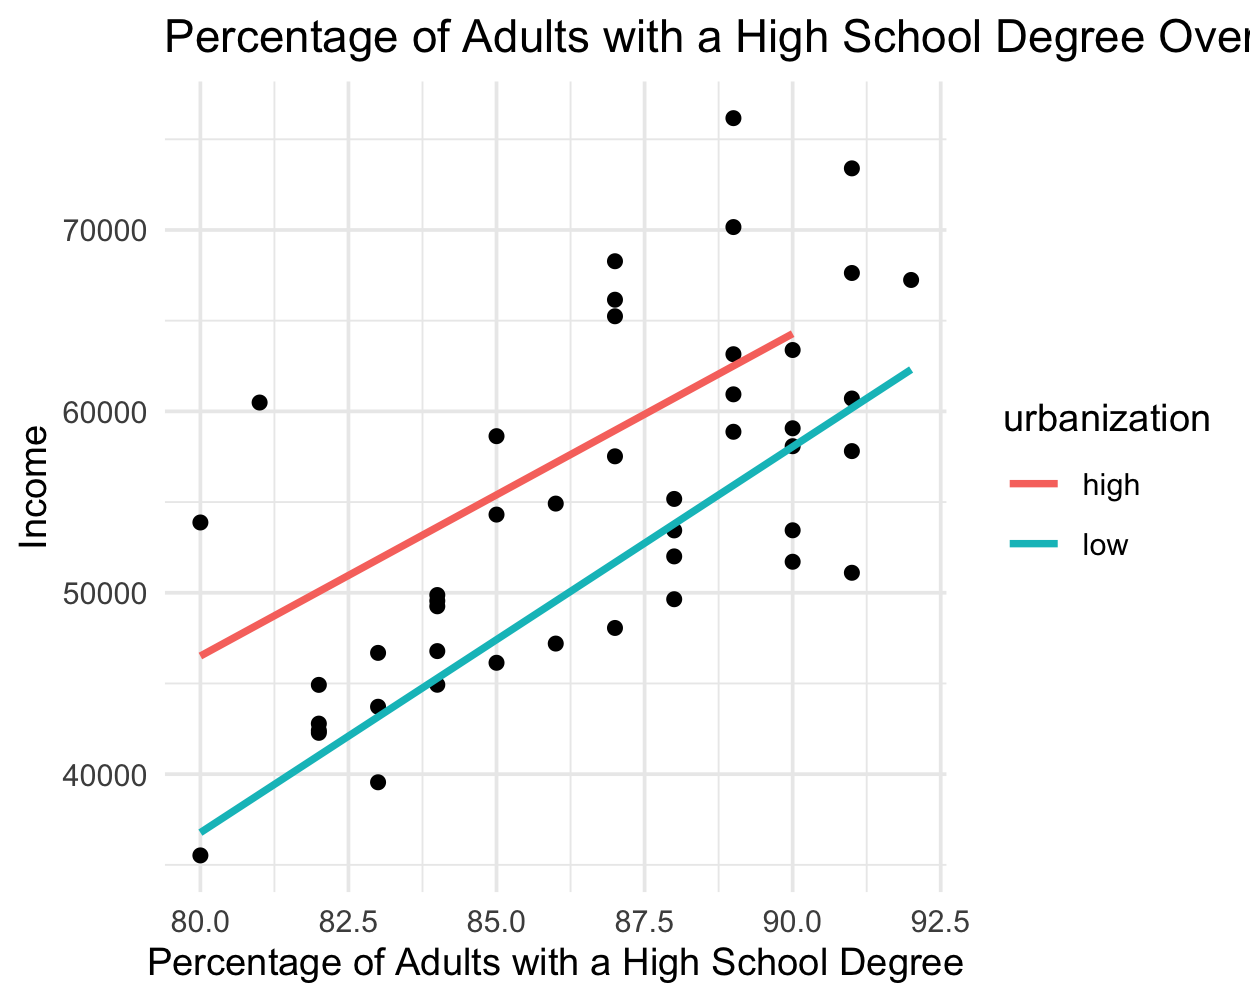

In [ ]:

ggplot(data = hate_crimes, aes(x = hs, y = income, hue = urbanization)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE, mapping = aes(color = urbanization)) +
  labs(title = "Percentage of Adults with a High School Degree Over Time",
       x = "Percentage of Adults with a High School Degree",
       y = "Income") +
  theme_minimal()


❓Based on visually comparing the two models shown above, do you think it would be best to run a “parallel slopes” model (i.e. a model that estimates one shared slope for the two levels of urbanization), or a more complex “interaction model” (i.e. a model that estimates a separate slope for the two levels of urbanization)?

**Answer:**

Based on the plot, it seems that the increase in income with percentage of high school degree is more in areas of low urbanization. The slope of the line for low urbanization is steeper than that for high urbanization, indicating that as the percentage of adults with a high school degree increases, income increases more rapidly in low urbanization areas compared to high urbanization areas.   

Fit the following two regression models that examine the relationship between household `income` (as response variable), and high-school education (`hs`) and `urbanization` as explanatory variables:

1. A parallel slopes model (i.e., no interaction between `hs` and `urbanization`). ❗️Save the data recipe and model under the variables `ps_rec` and `ps_mod`, respectively. 
1. A non-parallel slopes model (i.e., allow `hs` and `urbanization` to interact in your model). ❗️Save the data recipe and model under the variable: `nps_rec` and `nps_mod`, respectively.

**Code you your models in the cell below.**

In [ ]:
# parallel slopes model

ps_rec = recipe(income ~ hs + urbanization, data = hate_crimes) |> 
    step_naomit(everything()) |>   # remove missing values
    step_dummy(urbanization) |>    # dummy encode the urbanization variable
    prep()                         # run the recipe on the training data provided

mod = linear_reg() |> set_engine('lm')

ps_mod = mod |> fit(income ~ ., juice(ps_rec))

ps_mod


parsnip model object


Call:
stats::lm(formula = income ~ ., data = data)

Coefficients:
     (Intercept)                hs  urbanization_low  
         -114372              1994             -7469  


In [ ]:
# non-parallel slopes model

# ❗️ you can use most of the code above, just add step_interact(~ starts_with("urbanization"):hs) to the recipe and
#    switch the variable names...
nps_rec = recipe(income ~ hs + urbanization, data = hate_crimes) |> 
    step_naomit(everything()) |>   # remove missing values
    step_dummy(urbanization) |>    # dummy encode the urbanization variable
    step_interact(~ starts_with("urbanization"):hs) |>
    prep()                         # run the recipe on the training data provided

mod = linear_reg() |> set_engine('lm')

nps_mod = mod |> fit(income ~ ., juice(nps_rec))

nps_mod





parsnip model object


Call:
stats::lm(formula = income ~ ., data = data)

Coefficients:
          (Intercept)                     hs       urbanization_low  
             -95647.4                 1777.0               -37773.9  
urbanization_low_x_hs  
                350.5  


The following code creates a table of your model predictions over the training data. Calculate the [coefficient of determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) (R<sup>2</sup>) for each model:

```r
rbind(
    augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes"),
    augment(nps_mod, juice(nps_rec)) |> select(income, .pred, .resid) |> mutate(model = "interaction")
)
```

1. Group rows by the `model` variable (use the `group_by` function).
1. Calculate the variance of income over the variance of your predictions for each model using the "grouped" data from the step above (use `summarize(r_squared = var(.pred) / var(income))`).

In [ ]:

rbind(
    augment(ps_mod, juice(ps_rec)) |> select(income, .pred, .resid) |> mutate(model = "parallel_slopes"),
    augment(nps_mod, juice(nps_rec)) |> select(income, .pred, .resid) |> mutate(model = "interaction")
) |> group_by(model) |> summarize(r_squared = var(.pred) / var(income)) 


model,r_squared
<chr>,<dbl>
interaction,0.6068800
parallel_slopes,0.6032128


🎶 Note: you can also use the `glance` function with a model as input to find the coefficient of determination.

In [ ]:
glance(ps_mod)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.6032128,0.5843182,6095.036,31.9251,3.712875e-09,2,-454.4852,916.9705,924.1971,1560277443,42,45


In [ ]:
glance(nps_mod)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.60688,0.5781151,6140.345,21.09795,2.00388e-08,3,-454.2763,918.5527,927.586,1545857222,41,45


❓Compare the adjusted proportion of variance accounted for in each model. Based on this comparison, which model do you prefer? Why? 

**Answer:**

In [ ]:

Comparing the adjusted R-squared values of the two models, 
we can see that the non-parallel slopes model has a lower 
adjusted R-squared value than the parallel slopes model. 
This suggests that the parallel slopes model explains more of the 
variance in income than the non-parallel slopes model. 
Therefore, I would prefer the parallel slopes model as it provides a 
better fit to the data and accounts for more of the variability 
in income based on high school education and urbanization level.

❓Using your preferred model, based on your regression model parameters (and the data visualizations), is `income` greater in states that have lower or higher levels of `urbanization`? By how much?

**Hint:** use the `tidy` function with your model as input to access the parameters in a nice table.

**Answer:**

In [ ]:

# Using your preferred model, based on your regression model parameters (and the data visualizations), is `income` greater in states that have lower or higher levels of `urbanization`? By how much?
tidy(x = ps_mod)


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-114372.274,23560.4029,-4.854428,1.705441e-05
hs,1994.303,273.0468,7.303889,5.360071e-09
urbanization_low,-7469.399,1833.8327,-4.073108,2.010890e-04


Low-urbanization states have lower predicted income by 7649.

❓For every one percentage point increase of high-school educated adults in a state (`hs` variable), what is the associated average increase in `income`?

**Answer:**

In [ ]:

tidy(ps_mod) |> filter(term == "hs")



term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
hs,1994.303,273.0468,7.303889,5.360071e-09


For every one percentage point increase of high-school educated adults in a state , the associated average increase in income is 1994.
